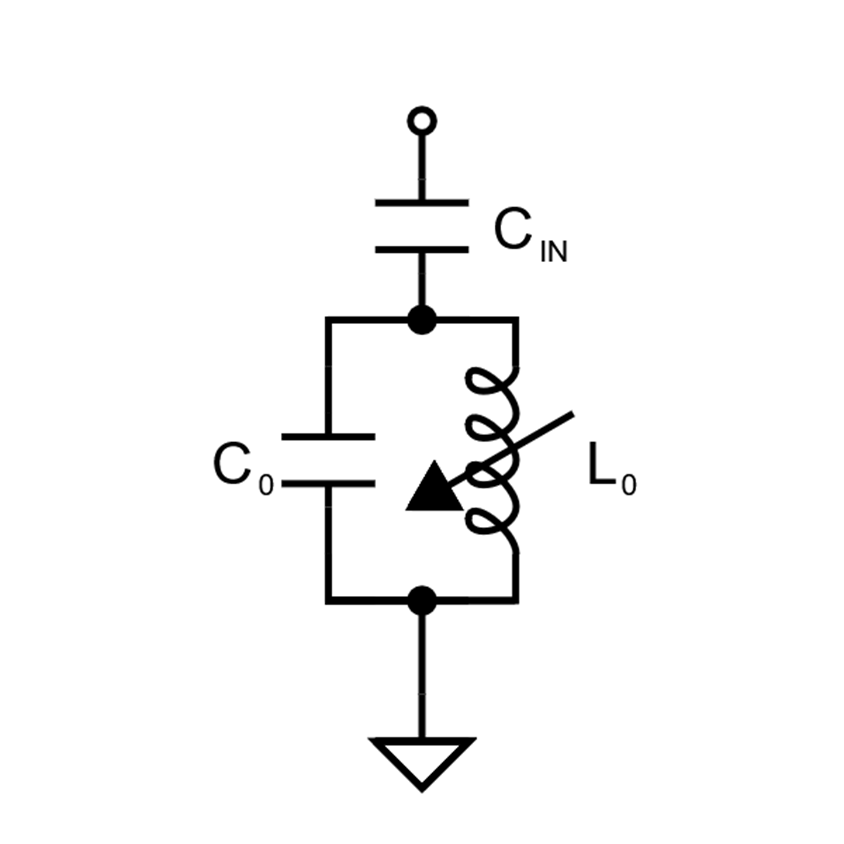

$$
Z_{LC} = \frac{\frac{1}{i\omega C_0} i\omega (L_0 + \frac{L_J}{\cos{2\pi\phi}})}{\frac{1}{i\omega C_0} + i\omega (L_0 + \frac{L_J}{\cos{2\pi\phi}})}
$$
$$
Z_{LC} = \frac{\frac{1}{i\omega C_0} i\omega L_0}{\frac{1}{i\omega C_0} + i\omega L_0}
$$
$$
Z_{LC} = \frac{\frac{1}{i\omega C_0} i\omega L_0}{\frac{1}{i\omega C_0} + i\omega L_0}\left(\frac{i\omega C_0}{i\omega C_0}\right)
$$


$$
Z = \frac{1}{i\omega C_{in}} + \frac{i\omega L_0}{1 - \omega^2C_0L_0}
$$

In [8]:
# load needed python libraries matplotlib, numpy, and scikit-rf
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
import json
from skrf.media import *
from skrf import Frequency
from scipy.optimize import curve_fit


In [ ]:
# Read in data corrected with E-cal 
data_corrected = rf.read_all('jpa-nopump-scan2-s1p-corrected')

In [46]:
# Read in raw data, un-corrected
data_raw = rf.read_all('jpa-nopump-scan2-s1p')

In [48]:
# Create frequency array
fghz = data_corrected['trace0'].f/1e9


In [58]:
# create flux bias array
file_object = open("biaswave.json", "r")
period = 1.85 # determined from looking at period of data sets
biaswave = json.loads(file_object.read())
file_object.close()
biaswave = np.array(biaswave)
phiwave = biaswave/period

(-180.0, 180.0)

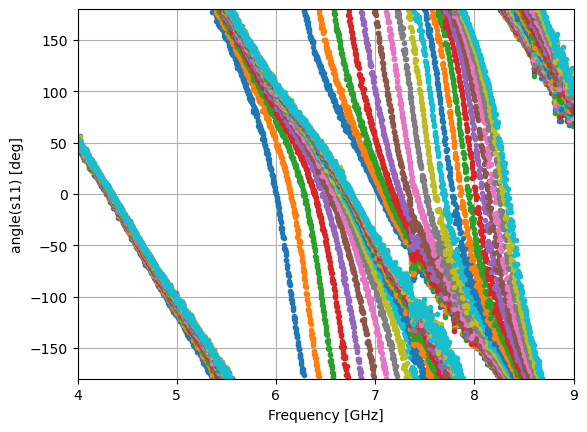

In [192]:
for index in range(20):
    plt.plot(fghz,np.angle(data_corrected['trace' + str(10*index)].s[:,0,0],deg=True),'.')

plt.grid()
plt.xlim(4,9)
plt.xlabel("Frequency [GHz]")
plt.ylabel("angle(s11) [deg]")
plt.ylim(-180,180)

$$
\times e^{2\pi  i  f t_{unwind}}
$$

(-180.0, 180.0)

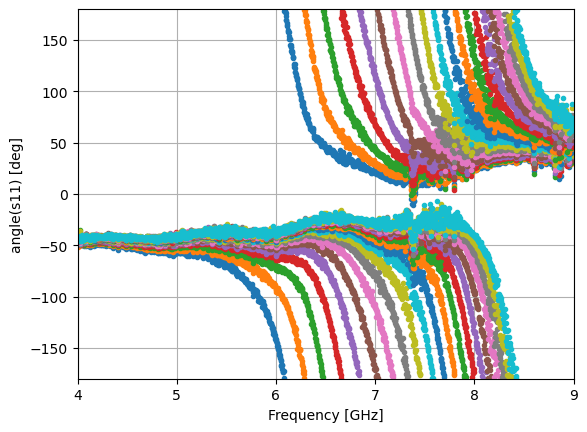

In [200]:
t_unwind = 0.434 # nanoseconds
for index in range(20):
    plt.plot(fghz,np.angle(np.exp(1j*2*np.pi*fghz*t_unwind)*data_corrected['trace' + str(10*index)].s[:,0,0],deg=True),'.')

plt.grid()
plt.xlim(4,9)
plt.xlabel("Frequency [GHz]")
plt.ylabel("angle(s11) [deg]")
plt.ylim(-180,180)

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
C:\Users\lfs\AppData\Local\Temp\1\ipykernel_19332\620287013.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.title('flux bias = ' + str(np.round(phiwave[460],4)) + ' $\phi_0$')


Text(0.5, 1.0, 'flux bias = -0.7294 $\\phi_0$')

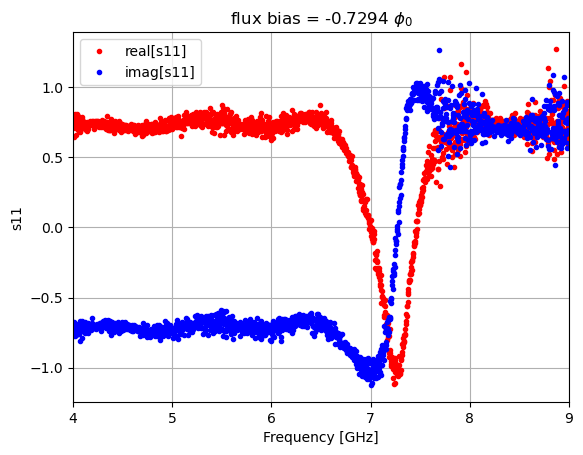

In [215]:
unwrapped_s = np.exp(1j*2*np.pi*fghz*t_unwind)*data_corrected['trace460'].s[:,0,0]

plt.plot(fghz,np.real(unwrapped_s),'.',color="red")
plt.plot(fghz,np.imag(unwrapped_s),'.',color="blue")
plt.grid()
plt.xlim(4,9)
plt.xlabel("Frequency [GHz]")
plt.ylabel("s11")
plt.legend(['real[s11]','imag[s11]'])
plt.title('flux bias = ' + str(np.round(phiwave[460],4)) + ' $\phi_0$')

In [219]:
s_unwrapped_real_imag_concat = []
for index in range(len(data_corrected)):
    unwrapped_s = np.exp(1j*2*np.pi*fghz*t_unwind)*data_corrected['trace' + str(index)].s[:,0,0]
    s_unwrapped_real_imag_concat.append(np.concatenate((np.real(unwrapped_s),np.imag(unwrapped_s))))

s_unwrapped_real_imag_concat  = np.array(s_unwrapped_real_imag_concat)

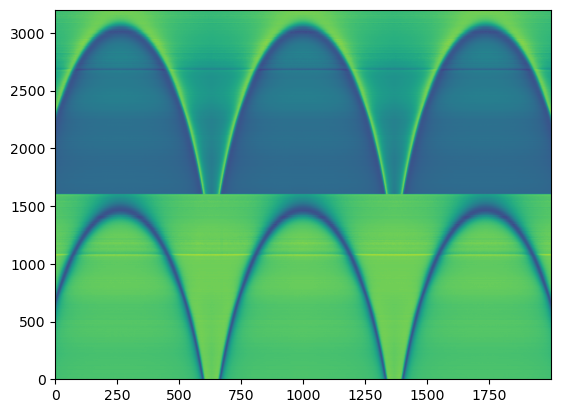

In [227]:
plt.imshow(s_unwrapped_real_imag_concat.transpose(),origin='lower',aspect='auto')

In [381]:
#Create fit function with frequency concatenated on itself and returning imag contatenated on top of real
def jpa_complex_concat(frequencyghzconcat, CinpF, C0pF, L0pH, tau):
    halfnumber = int(len(frequencyghzconcat)/2)
    frequencyghz = frequencyghzconcat[0:halfnumber]
    Cin = CinpF*1e-12
    C0 = C0pF*1e-12
    L0 = L0pH*1e-12
    omega = 2*np.pi*frequencyghz*1e9
    Z_jpa = (1/(1j*omega*Cin)) + (1j*omega*L0)/(1 - omega*omega*C0*L0)
    s_jpa = (Z_jpa  - 50)/(Z_jpa + 50)
    s_jpa = s_jpa*np.exp(1j*2*np.pi*frequencyghz*tau)
    s_jpa_concat = np.concatenate((np.real(s_jpa),np.imag(s_jpa)))
    return s_jpa_concat # this minus sign is suspect, i have no idea why it's here
    
def jpa_complex(frequencyghz, CinpF, C0pF, L0pH, tau):
    Cin = CinpF*1e-12
    C0 = C0pF*1e-12
    L0 = L0pH*1e-12
    omega = 2*np.pi*frequencyghz*1e9
    Z_jpa = (1/(1j*omega*Cin)) + (1j*omega*L0)/(1 - omega*omega*C0*L0)
    s_jpa = (Z_jpa - 50)/(Z_jpa + 50)
    s_jpa = s_jpa*np.exp(-1j*2*np.pi*frequencyghz*tau)    
    return s_jpa 

In [231]:
fghzfghz = np.concatenate((fghz,fghz))

Text(0.5, 0, '')

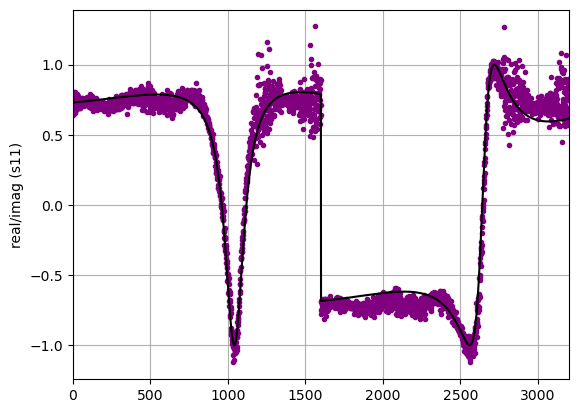

In [383]:
f0ghz_360_data = 2.3
f0ghz_360_theory = -21
Cinguess = 1 #  pF
C0guess = 5.2 # pF
L0guess = 88 #  pH
tauguess = 0.047

popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, s_unwrapped_real_imag_concat[460],p0=[Cinguess,C0guess,L0guess,tauguess],bounds=((0.4*Cinguess,0.4*C0guess,0.2*L0guess,0.8*tauguess),(1.2*Cinguess,1.2*C0guess,3*L0guess,1.2*tauguess)))

plt.plot(s_unwrapped_real_imag_concat[460],'.',color='purple')
#plt.plot(jpa_complex_concat(fghzfghz,1,5.2,88,-0.047),color='black')
plt.plot(jpa_complex_concat(fghzfghz,popt[0],popt[1],popt[2],popt[3]),color='black')
plt.xlim(0,len(fghzfghz))
plt.grid()
plt.ylabel('real/imag (s11)')
plt.xlabel('')

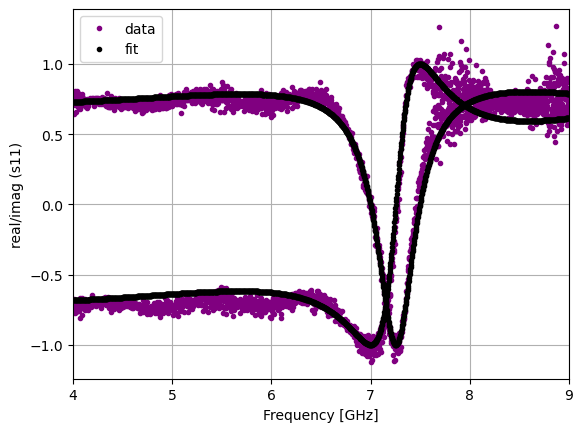

In [385]:
plt.plot(fghzfghz,s_unwrapped_real_imag_concat[460],'.',color='purple')
plt.plot(fghzfghz,jpa_complex_concat(fghzfghz,popt[0],popt[1],popt[2],popt[3]),'.',color='black')
plt.xlim(fghzfghz[0],fghzfghz[len(fghzfghz)-1])
plt.grid()
plt.ylabel('real/imag (s11)')
plt.xlabel('Frequency [GHz]')
plt.legend(['data','fit'])

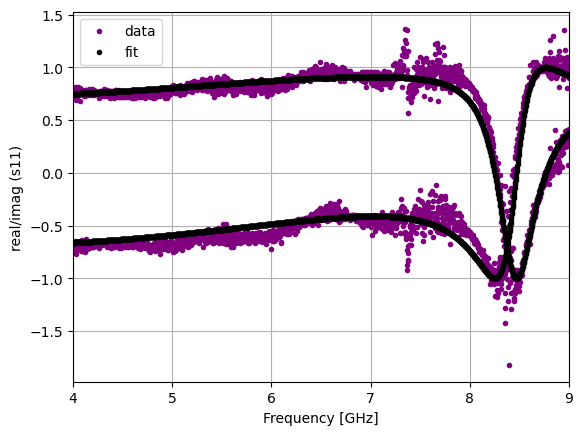

In [389]:
phiindex = 200
popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, s_unwrapped_real_imag_concat[phiindex],p0=[Cinguess,C0guess,L0guess,tauguess],bounds=((0.4*Cinguess,0.4*C0guess,0.2*L0guess,0.8*tauguess),(1.2*Cinguess,1.2*C0guess,3*L0guess,2*tauguess)))
plt.plot(fghzfghz,s_unwrapped_real_imag_concat[phiindex],'.',color='purple')
plt.plot(fghzfghz,jpa_complex_concat(fghzfghz,popt[0],popt[1],popt[2],popt[3]),'.',color='black')
plt.xlim(fghzfghz[0],fghzfghz[len(fghzfghz)-1])
plt.grid()
plt.ylabel('real/imag (s11)')
plt.xlabel('Frequency [GHz]')
plt.legend(['data','fit'])
#plt.xlim(5.5,6.5)

In [391]:
Cinwave = []
C0wave = []
L0wave = []
tauwave = []
Cinsigmawave = []
C0sigmawave = []
L0sigmawave = []
tausigmawave = []
for phiindex in range(200):
    popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, s_unwrapped_real_imag_concat[phiindex],p0=[Cinguess,C0guess,L0guess,tauguess],bounds=((0.4*Cinguess,0.4*C0guess,0.2*L0guess,0.8*tauguess),(1.2*Cinguess,1.3*C0guess,3*L0guess,2*tauguess)))
    Cinwave.append(popt[0])
    C0wave.append(popt[1])
    L0wave.append(popt[2])
    tauwave.append(popt[3])    
    Cinsigmawave.append(np.sqrt(pcov[0,0]))
    C0sigmawave.append(np.sqrt(pcov[1,1]))
    L0sigmawave.append(np.sqrt(pcov[2,2]))
    tausigmawave.append(np.sqrt(pcov[3,3]))
Cinwave = np.array(Cinwave)
C0wave = np.array(C0wave)
L0wave = np.array(L0wave)
tauwave = np.array(tauwave)
Cinsigmawave = np.array(Cinsigmawave)
C0sigmawave = np.array(C0sigmawave)
L0sigmawave = np.array(L0sigmawave)
tausigmawave = np.array(tausigmawave)


Text(0.5, 0, 'flux bias [per flux quantum]')

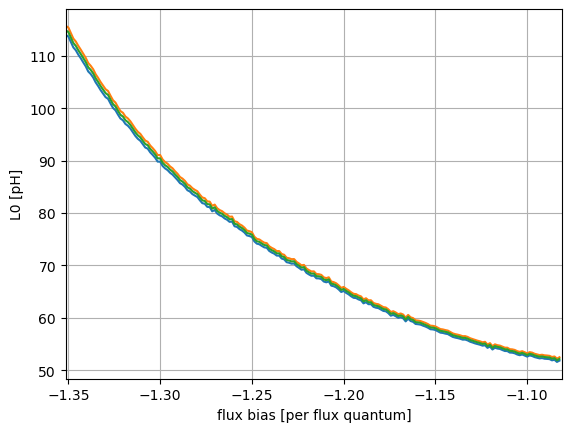

In [393]:
plt.plot(phiwave[0:200],L0wave - L0sigmawave)
plt.plot(phiwave[0:200],L0wave + L0sigmawave)
plt.plot(phiwave[0:200],L0wave)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('L0 [pH]')
plt.xlabel('flux bias [per flux quantum]')

Text(0.5, 1.0, '5th order polynomial fit')

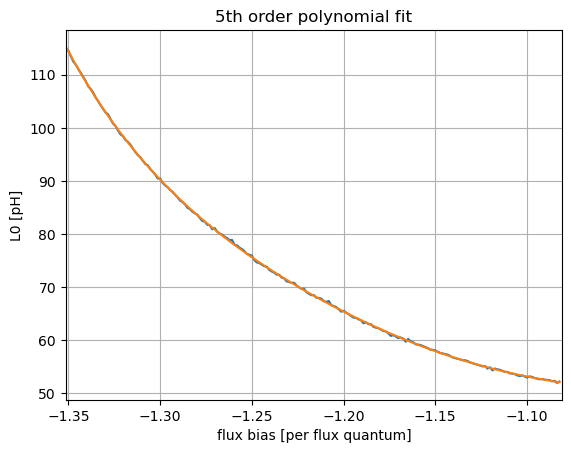

In [367]:
plt.plot(phiwave[0:200],L0wave)
polyterms = np.polyfit(phiwave[0:200],L0wave,5)
Lpoly = polyterms[0]*phiwave[0:200]**5 + polyterms[1]*phiwave[0:200]**4 +polyterms[2]*phiwave[0:200]**3 +polyterms[3]*phiwave[0:200]**2 + polyterms[4]*phiwave[0:200] + polyterms[5]
plt.plot(phiwave[0:200],Lpoly)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('L0 [pH]')
plt.xlabel('flux bias [per flux quantum]')
plt.title('5th order polynomial fit')

(-2.0, 2.0)

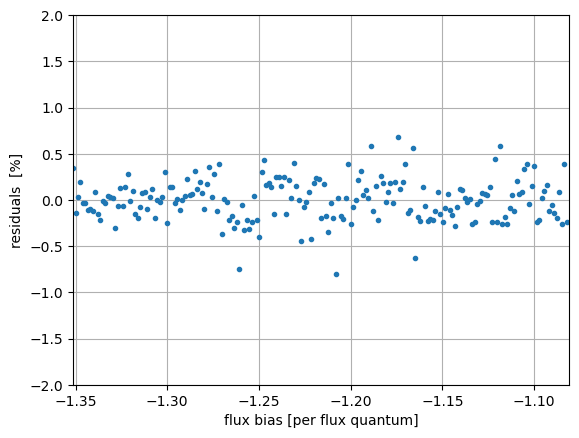

In [369]:
plt.plot(phiwave[0:200],100*(Lpoly - L0wave)/L0wave,'.')
plt.xlabel('flux bias [per flux quantum]')
plt.grid()
plt.ylabel('residuals  [%]')
plt.xlim(phiwave[0],phiwave[200])
plt.ylim(-2,2)

Text(0.5, 1.0, 'line is at 1.2 pF')

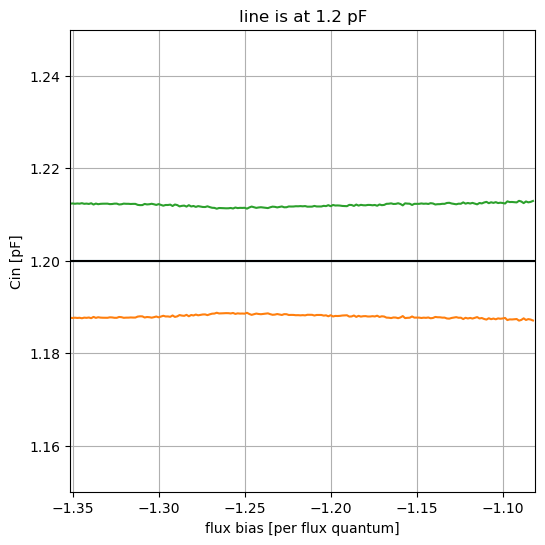

In [371]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],Cinwave)
plt.plot(phiwave[0:200],Cinwave  -Cinsigmawave)
plt.plot(phiwave[0:200],Cinwave +Cinsigmawave)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylim(1.15,1.25)
plt.ylabel('Cin [pF]')
plt.xlabel('flux bias [per flux quantum]')
plt.hlines([1.2],phiwave[0],phiwave[200],color="black")
plt.title('line is at 1.2 pF')

Text(0.5, 0, 'flux bias [per flux quantum]')

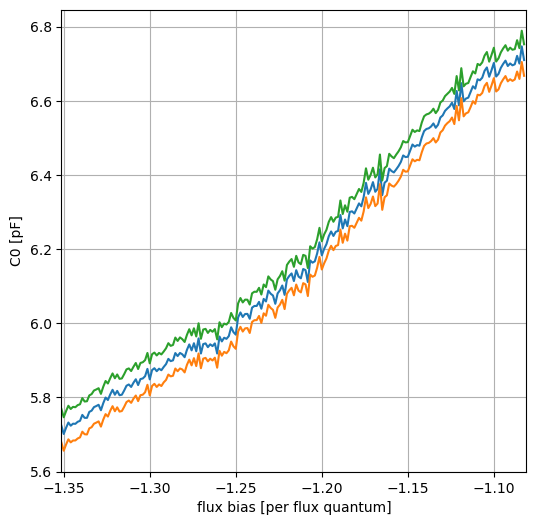

In [373]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],C0wave)
plt.plot(phiwave[0:200],C0wave  - C0sigmawave)
plt.plot(phiwave[0:200],C0wave +  C0sigmawave)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('C0 [pF]')
plt.xlabel('flux bias [per flux quantum]')

Text(0.5, 0, 'flux bias [per flux quantum]')

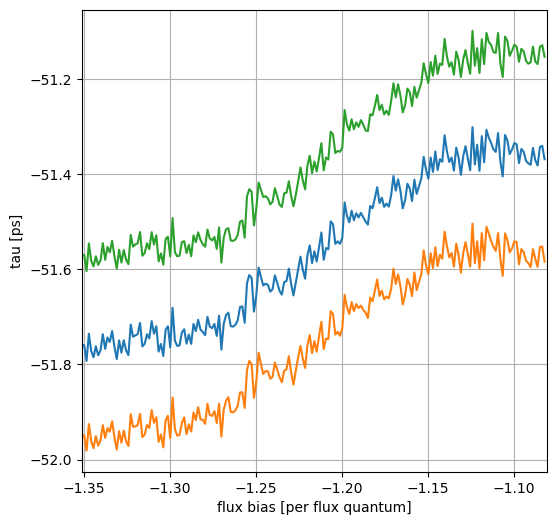

In [379]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],1e3*tauwave)
plt.plot(phiwave[0:200],1e3*tauwave  - 1e3*tausigmawave)
plt.plot(phiwave[0:200],1e3*tauwave + 1e3*tausigmawave)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('tau [ps]')
plt.xlabel('flux bias [per flux quantum]')

In [407]:
np.argmin(np.abs((phiwave[0:200]+ 1.2)))

112

Text(0.5, 1.0, 'index = 20, phi = -1.3243')

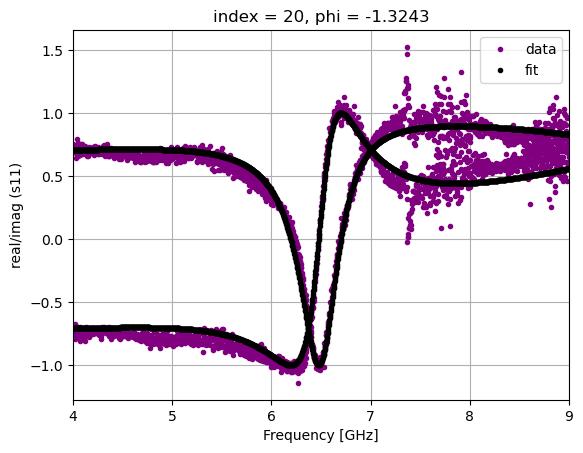

In [421]:
phiindex = 20
popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, s_unwrapped_real_imag_concat[phiindex],p0=[Cinguess,C0guess,L0guess,tauguess],bounds=((0.4*Cinguess,0.4*C0guess,0.2*L0guess,0.8*tauguess),(1.2*Cinguess,1.2*C0guess,3*L0guess,2*tauguess)))
plt.plot(fghzfghz,s_unwrapped_real_imag_concat[phiindex],'.',color='purple')
plt.plot(fghzfghz,jpa_complex_concat(fghzfghz,popt[0],popt[1],popt[2],popt[3]),'.',color='black')
plt.xlim(fghzfghz[0],fghzfghz[len(fghzfghz)-1])
plt.grid()
plt.ylabel('real/imag (s11)')
plt.xlabel('Frequency [GHz]')
plt.legend(['data','fit'])
plt.title('index = ' + str(phiindex) + ', phi = ' + str(np.round(phiwave[phiindex],4)))

In [427]:
Cinwave[20],C0wave[20], tauwave[20]


(1.1999999999999997, 5.792853527063269, 0.05178045723969241)